In [74]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


## Load Dataset

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv", encoding="ISO-8859-1")

# show the first 5 rows of the dataframe
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Step1: Data exploration


In [76]:

# number of rows,columns and missing values in the dataframe
df.info()
#shows statistics like mean,mediaan,standard deviation
df.describe()



<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# Step2: Data cleaning

In [77]:
df.isnull().sum()#this checks for missing values in the dataframe and sums them up for each column
df = df.dropna(subset=['CustomerID'])#this drops rows where customer id is missing 
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])#this converts the invoice date column to a datetime format which allows us to perform date related operations on it
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Step3: Feature Engineering
Here new variables from the raw dataset is created to help us to analyze customer behavior and business performance.
We identified the top 10 customers based on total spending. This helps us understand revenue concentration and customer value distribution within the dataset.

The analysis shows whether sales are driven by a small group of high-value customers or distributed evenly across many buyers.

## Total price

We create a new column called `TotalPrice` by multiplying `Quantity` and `UnitPrice`.

This shows how much money each transaction generated. It helps us understand the revenue from every purchase.

In [78]:
df.columns
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df = df[df['TotalPrice'] > 0]


## Create time based feature

We create a new column called `Month` by extracting the month from the `InvoiceDate`.

This helps us group sales by time and analyze monthly trends in revenue.

In [79]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

## Step4: Data Analysis

In this step, we analyze the dataset using the features we created during feature engineering, such as TotalPrice and time-based columns.

We use these features to explore customer behavior, revenue patterns, and key trends in the data.

In [80]:
grouped = df.groupby('CustomerID')
customer_df = grouped['TotalPrice'].sum().reset_index()
customer_df.columns = ['CustomerID', 'TotalSpent']

## Technique 1: Customer Segmentation Using Quantiles

Customers are grouped into spending categories (Low, Medium, High, VIP) based on their total spending. This helps simplify customer behavior and makes it easier to identify different value levels.


In [81]:
quantiles = df['TotalPrice'].quantile([0.25, 0.5, 0.75, 0.99])
quantiles

0.25      4.68
0.50     11.80
0.75     19.80
0.99    202.50
Name: TotalPrice, dtype: float64

In [82]:
customer_df = df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
customer_df.columns = ['CustomerID', 'TotalSpent']
customer_df['TotalSpent'].describe()# this gives us the count, mean, standard deviation, minimum, 25th percentile, median, 75th percentile and maximum of the total spent by customers.

count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: TotalSpent, dtype: float64

In [83]:
q1 = customer_df['TotalSpent'].quantile(0.25)
q2 = customer_df['TotalSpent'].quantile(0.5)
q3 = customer_df['TotalSpent'].quantile(0.75)

def segment(x):
    if x <= q1:
        return "Low"
    elif x <= q2:
        return "Medium"
    elif x <= q3:
        return "High"
    else:
        return "VIP"

customer_df['Segment'] = customer_df['TotalSpent'].apply(segment)
customer_df['Segment'].value_counts()

Segment
VIP       1085
Low       1085
Medium    1084
High      1084
Name: count, dtype: int64

## Technique 2: outlier analysis

This code identifies customers with extremely high spending compared to others. These outliers may represent VIP customers.

In [84]:
customer_df['TotalSpent'].describe()

count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: TotalSpent, dtype: float64

In [85]:

outliers = customer_df[customer_df['TotalSpent'] > customer_df['TotalSpent'].quantile(0.99)]
outliers

,CustomerID,TotalSpent,Segment
0,12346.0,77183.60,VIP
55,12415.0,124914.53,VIP
324,12744.0,21279.29,VIP
326,12748.0,33719.73,VIP
330,12753.0,21429.39,VIP
453,12931.0,42055.96,VIP
558,13081.0,28337.38,VIP
562,13089.0,58825.83,VIP
570,13098.0,28882.44,VIP
795,13408.0,28117.04,VIP


## Technique 3: country vs Revenue

This analysis compares total revenue across different counries to understand how sales are distributed within countrys. This helps to identify which countries contributes the most revenue.

In [86]:
cross_table = pd.crosstab(df['Country'], df['Quantity'], values=df['TotalPrice'], aggfunc='sum')

country_revenue = cross_table.sum(axis=1).sort_values(ascending=False)

country_revenue

Country
United Kingdom          7308391.554
Netherlands              285446.340
EIRE                     265545.900
Germany                  228867.140
France                   209024.050
Australia                138521.310
Spain                     61577.110
Switzerland               56443.950
Belgium                   41196.340
Sweden                    38378.330
Japan                     37416.370
Norway                    36165.440
Portugal                  33439.890
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20450.440
Denmark                   18955.340
Italy                     17483.240
Cyprus                    13590.380
Austria                   10198.680
Poland                     7334.650
Israel                     7221.690
Greece                     4760.520
Iceland                    4310.000
Canada                     3666.380
USA                        3580.390
Malta                      2725.590
Unspecified         

## Technique 4: country contribution 

This help to show how much money each country contributes and ranking of markets.

<Axes: xlabel='Country'>

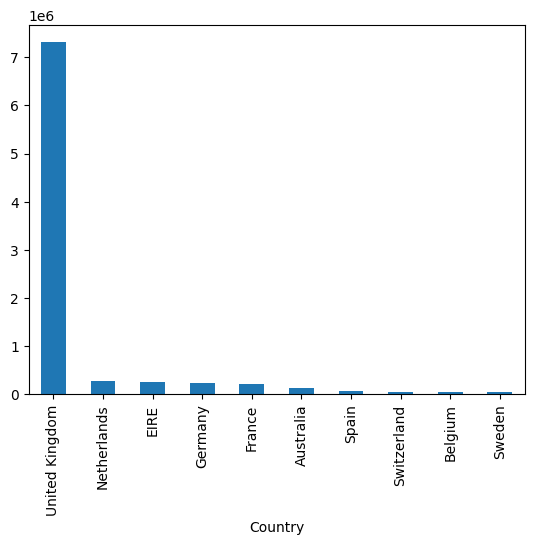

In [87]:
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
country_revenue
country_revenue.head(10).plot(kind='bar')

## Technique 5: Time-based patterns

This techniques looks at how the data changes over time. and the graph that keeps only the first 10 months data. 

<Axes: xlabel='InvoiceDate'>

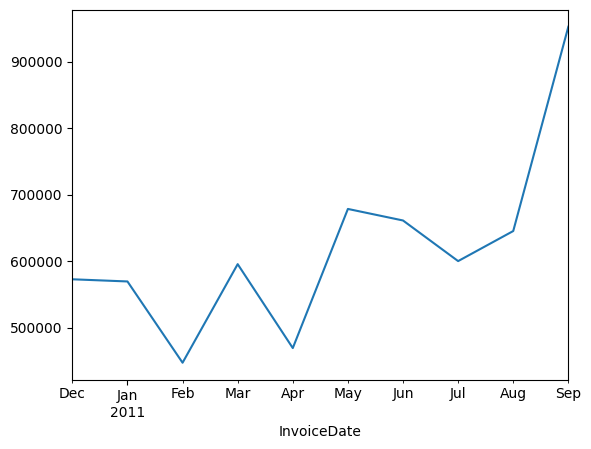

In [88]:
monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()
monthly_sales
monthly_sales.head(10).plot(kind='line')# 

# Technique 6:Revenue Distribution 

Text(0.5, 1.0, 'Distribution of Total Price')

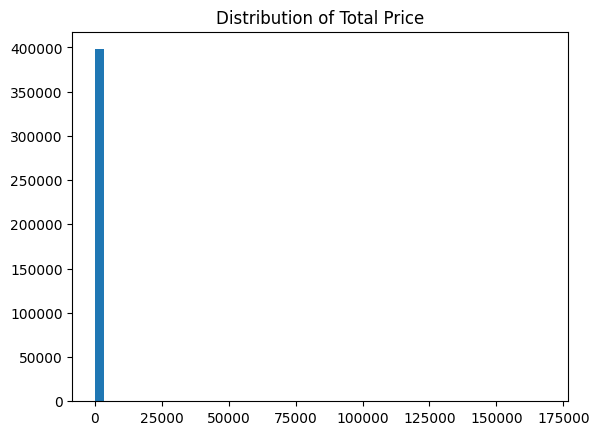

In [89]:
df['TotalPrice'].describe()
plt.hist(df['TotalPrice'], bins=50)# th
plt.title('Distribution of Total Price') 

From the graph we can generalize that 
--> most customers spend little
--> few customers spend a lot

### Top Customers Analysis

This analysis identifies the highest spending customers in the dataset. It helps highlight VIP customers who contribute significantly to total revenue.

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalPrice, dtype: float64


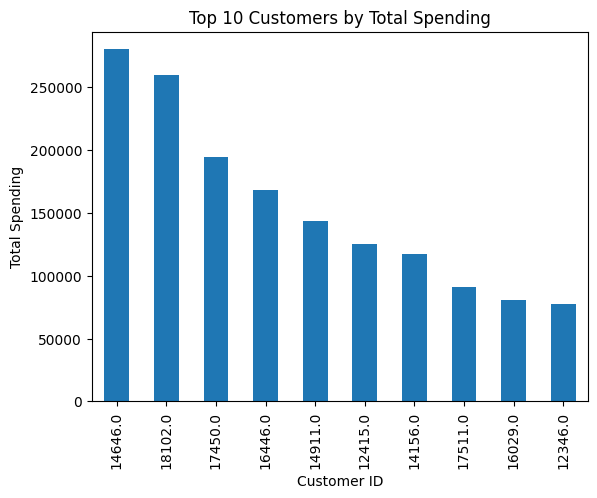

In [90]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

print(top_customers)

top_customers.plot(kind='bar')
plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spending')
plt.show()

## Step5: Insights

### 1. Extreme Revenue Concentration (VIP Effect)
A very small group of VIP customers contributes a disproportionately large share of total revenue, with some customers spending over 100,000+ units.

This shows that the business is heavily dependent on a small number of high-value customers, meaning customer retention is more critical than mass acquisition.


### 2. Highly Skewed Spending Distribution
Customer spending is highly uneven:

- 25th percentile: 4.20  
- 50th percentile (median): 11.10  
- 75th percentile: 19.50  
- 99th percentile: 199.68  

This indicates that most customers spend very little, while a small group spends extremely high amounts, creating a long-tail distribution.


### 3. Strong Geographic Imbalance in Revenue
Revenue is highly concentrated in a few countries such as the United Kingdom, while most other countries contribute significantly less.

This indicates that the business is not globally balanced and has strong dependency on one dominant market.



### 4. Clear Customer Segmentation Pattern
Customers naturally fall into distinct spending groups (Low, Medium, High, VIP) when analyzed using quantiles, with each segment containing a roughly equal number of customers.

This shows that customer behavior is structured, allowing businesses to apply targeted marketing strategies for each segment.



### 5. Presence of Extreme Outliers
The dataset contains extreme high-spending customers far beyond the normal range, with maximum spending significantly higher than typical values.

These outliers strongly influence total revenue and represent highly valuable customers who are critical to overall business performance.



### 6. Time-Based Revenue Variation
Revenue changes over time, showing fluctuations rather than a constant trend, suggesting possible seasonal or event-based buying behavior.

This indicates that timing plays an important role in sales performance and can be used for planning promotions and inventory.

## Conclusion

In this project, customer data was analyzed to understand buying behavior. The results show that a small number of customers spend a large amount of money, while most customers spend less.

It was also found that sales are higher in some countries compared to others, and spending changes over time. This means the business depends on a few important customers and specific markets.

Overall, this analysis helps the business understand its customers better and make smarter decisions in the future.